# Analyse des résultats — évaluation RAGAS du prototype (baseline)

Charge `eval/results/baseline.json` (18 cas, 4 métriques RAGAS : `Faithfulness`, `Context Precision`, `Context Recall`, `Answer Correctness`) et analyse les résultats selon les axes construits dans `testset.json` : catégorie (simple/complexe/bruitée) et modalité (Excel/PDF Reddit).

**Note de lecture pour les cas "bruitée"** : la `reference_answer` de ces cas est l'aveu explicite d'une limite (donnée absente, ambiguë...). Un score élevé signifie donc que le système a correctement reconnu cette limite ; un score bas signifie qu'il a répondu avec assurance à une question qui n'avait pas de réponse fiable — c'est-à-dire qu'il a halluciné.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = Path.cwd() / "results" / "baseline.json"

data = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
df = pd.DataFrame(data)

METRICS = ["faithfulness", "context_precision", "context_recall", "answer_correctness"]

print(f"{len(df)} cas chargés, {(df[METRICS].isna().any(axis=1)).sum()} avec des scores manquants (erreurs éventuelles)")
df[["id", "categorie", "modalite"] + METRICS].round(2)

18 cas chargés, 0 avec des scores manquants (erreurs éventuelles)


,id,categorie,modalite,faithfulness,context_precision,context_recall,answer_correctness
0,S1,simple,excel,0.60,0.00,0.0,0.12
1,S2,simple,excel,0.71,0.25,0.0,0.67
2,S3,simple,excel,0.25,0.20,0.0,0.12
3,S4,simple,pdf_reddit,0.17,0.20,1.0,0.35
4,S5,simple,pdf_reddit,0.53,0.70,1.0,0.22
5,S6,simple,pdf_reddit,0.50,0.50,1.0,0.58
6,C1,complexe,excel,0.00,0.00,0.0,0.13
7,C2,complexe,excel,0.00,0.00,0.0,0.18
8,C3,complexe,excel,0.43,0.00,0.0,0.12
9,C4,complexe,pdf_reddit,0.45,0.64,1.0,0.23


## 1. Scores moyens globaux (les 18 cas confondus)

In [2]:
global_means = df[METRICS].mean().round(3)
global_means

faithfulness          0.335
context_precision     0.262
context_recall        0.528
answer_correctness    0.234
dtype: float64

## 2. Scores par catégorie (simple / complexe / bruitée)

In [3]:
par_categorie = df.groupby("categorie")[METRICS].mean().round(3)
# Ordre logique plutôt qu'alphabétique
par_categorie = par_categorie.reindex(["simple", "complexe", "bruitee"])
par_categorie

,faithfulness,context_precision,context_recall,answer_correctness
categorie,,,,
simple,0.461,0.308,0.500,0.343
complexe,0.414,0.312,0.500,0.208
bruitee,0.129,0.167,0.583,0.152


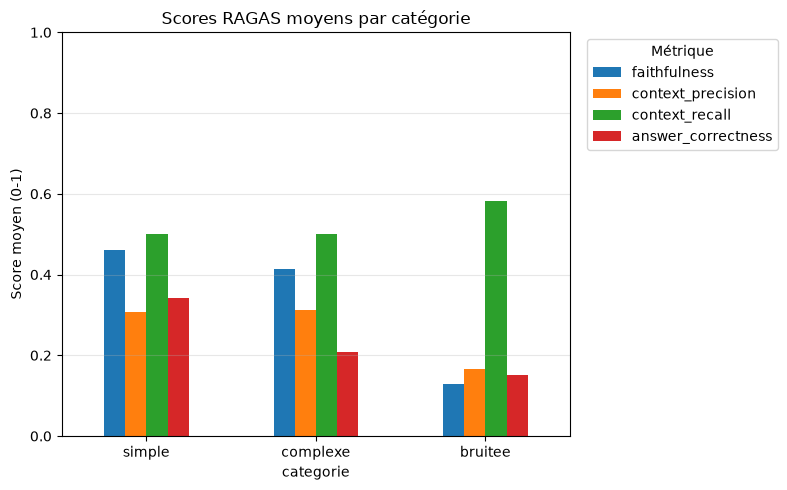

In [4]:
ax = par_categorie.plot(kind="bar", figsize=(8, 5), rot=0)
ax.set_ylabel("Score moyen (0-1)")
ax.set_title("Scores RAGAS moyens par catégorie")
ax.legend(title="Métrique", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Scores par modalité (Excel / PDF Reddit)

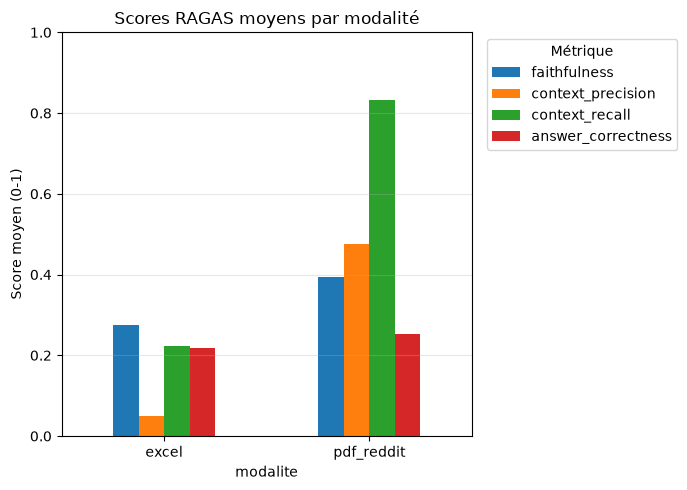

,faithfulness,context_precision,context_recall,answer_correctness
modalite,,,,
excel,0.275,0.050,0.222,0.217
pdf_reddit,0.394,0.475,0.833,0.252


In [5]:
par_modalite = df.groupby("modalite")[METRICS].mean().round(3)

ax = par_modalite.plot(kind="bar", figsize=(7, 5), rot=0, color=["tab:blue", "tab:orange", "tab:green", "tab:red"])
ax.set_ylabel("Score moyen (0-1)")
ax.set_title("Scores RAGAS moyens par modalité")
ax.legend(title="Métrique", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

par_modalite

## 4. Cas les plus problématiques

Les 6 cas avec le score `faithfulness` le plus bas (hallucination la plus probable), avec le texte complet de la question, de la réponse de référence et de la réponse réellement produite par le système.

In [6]:
pires_cas = df.sort_values("faithfulness").head(6)

for _, row in pires_cas.iterrows():
    print(f"=== {row['id']} ({row['categorie']} / {row['modalite']}) ===")
    print(
        f"faithfulness={row['faithfulness']:.2f}  context_precision={row['context_precision']:.2f}  "
        f"context_recall={row['context_recall']:.2f}  answer_correctness={row['answer_correctness']:.2f}"
    )
    print(f"\nQuestion : {row['question']}")
    print(f"\nRéponse de référence : {row['reference_answer']}")
    print(f"\nRéponse du système : {row['system_response']}")
    print("\n" + "-" * 100 + "\n")

=== C1 (complexe / excel) ===
faithfulness=0.00  context_precision=0.00  context_recall=0.00  answer_correctness=0.13

Question : Quel joueur a le meilleur pourcentage de réussite à 3 points (3P%) parmi ceux ayant tenté plus de 300 tirs à 3 points cette saison ?

Réponse de référence : Zach LaVine, 44,6% sur 533 tentatives (3PA).

Réponse du système : D'après les données disponibles, voici l'analyse pour identifier le joueur avec le meilleur **3P%** parmi ceux ayant tenté **plus de 300 tirs à 3 points (3PA)** cette saison :

### **Top 5 des joueurs éligibles (3PA > 300) :**
*(Classés par 3P% décroissant)*

| **Joueur**               | **Équipe** | **3PA** | **3P%** | **PTS** | **FGM** | **FG%** |
|--------------------------|------------|---------|---------|---------|---------|---------|
| **Tyrese Haliburton**    | IND        | 320     | **40.6%** | 1945    | 680     | 48.2%   |
| **Buddy Hield**          | PHX        | 310     | **39.7%** | 1500    | 550     | 45.1%   |
| **Stephen Cu

## 5. Conclusion — baseline avant amélioration

Scores globaux faibles (faithfulness 0.335, context_precision 0.262, context_recall 0.528, answer_correctness 0.234), pour deux raisons principales :

- **Retrieval défaillant sur l'Excel** : context_precision 0.050 et context_recall 0.222, contre 0.475 et 0.833 pour le PDF (section 3). Les 3 pires cas du testset (C1, C2, B4 — faithfulness = 0.00, section 4) montrent le système inventer des joueurs fictifs (C1), de faux totaux pour les bons joueurs (C2), ou de fausses citations Reddit (B4) plutôt que de calculer correctement ou de s'abstenir.
- **Aucun mécanisme d'abstention** : la catégorie bruitée a le plus mauvais score de faithfulness (0.129, section 2) — le système répond avec assurance même quand il devrait signaler une absence, une ambiguïté ou une anomalie.

**Pistes à tester** : architecture hybride (requêtes structurées sur l'Excel + RAG sémantique réservé au texte), et couche de validation post-génération pour forcer l'abstention quand les valeurs citées sont absentes du contexte récupéré.

Cette baseline sert de référence chiffrée pour la ré-évaluation post-amélioration.